In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import numpy as np

In [3]:
df = pd.read_csv("oral_cancer.csv")

In [4]:
df.head()

,ID,Country,Gender,Age,Tobacco_Use,Alcohol_Use,Socioeconomic_Status,Diagnosis_Stage,Treatment_Type,Survival_Rate,HPV_Related
0,1,Ethiopia,Male,34,1,1,High,Early,Radiotherapy,0.826235,0
1,2,Turkey,Female,84,1,1,High,Moderate,Radiotherapy,0.376607,0
2,3,Turkey,Female,62,1,1,Middle,Early,Radiotherapy,0.736296,1
3,4,Tanzania,Male,48,1,1,Middle,Moderate,Combination,0.786118,0
4,5,France,Male,26,1,1,Middle,Early,Radiotherapy,0.830411,0


In [5]:
df.groupby(["Tobacco_Use", "Alcohol_Use","Treatment_Type"])["Survival_Rate"].agg(
    ["mean"]).reset_index()

,Tobacco_Use,Alcohol_Use,Treatment_Type,mean
0,0,0,Chemotherapy,0.600942
1,0,0,Combination,0.598450
2,0,0,Palliative,0.598318
3,0,0,Radiotherapy,0.604733
4,0,0,Surgery,0.600577
5,0,1,Chemotherapy,0.597699
6,0,1,Combination,0.602990
7,0,1,Palliative,0.601141
8,0,1,Radiotherapy,0.599477
9,0,1,Surgery,0.599291


In [6]:
df.groupby(["Tobacco_Use", "Alcohol_Use","HPV_Related"])["Survival_Rate"].agg(
    ["mean"]).reset_index()

,Tobacco_Use,Alcohol_Use,HPV_Related,mean
0,0,0,0,0.602083
1,0,0,1,0.598919
2,0,1,0,0.600051
3,0,1,1,0.599014
4,1,0,0,0.598447
5,1,0,1,0.601809
6,1,1,0,0.600017
7,1,1,1,0.599741


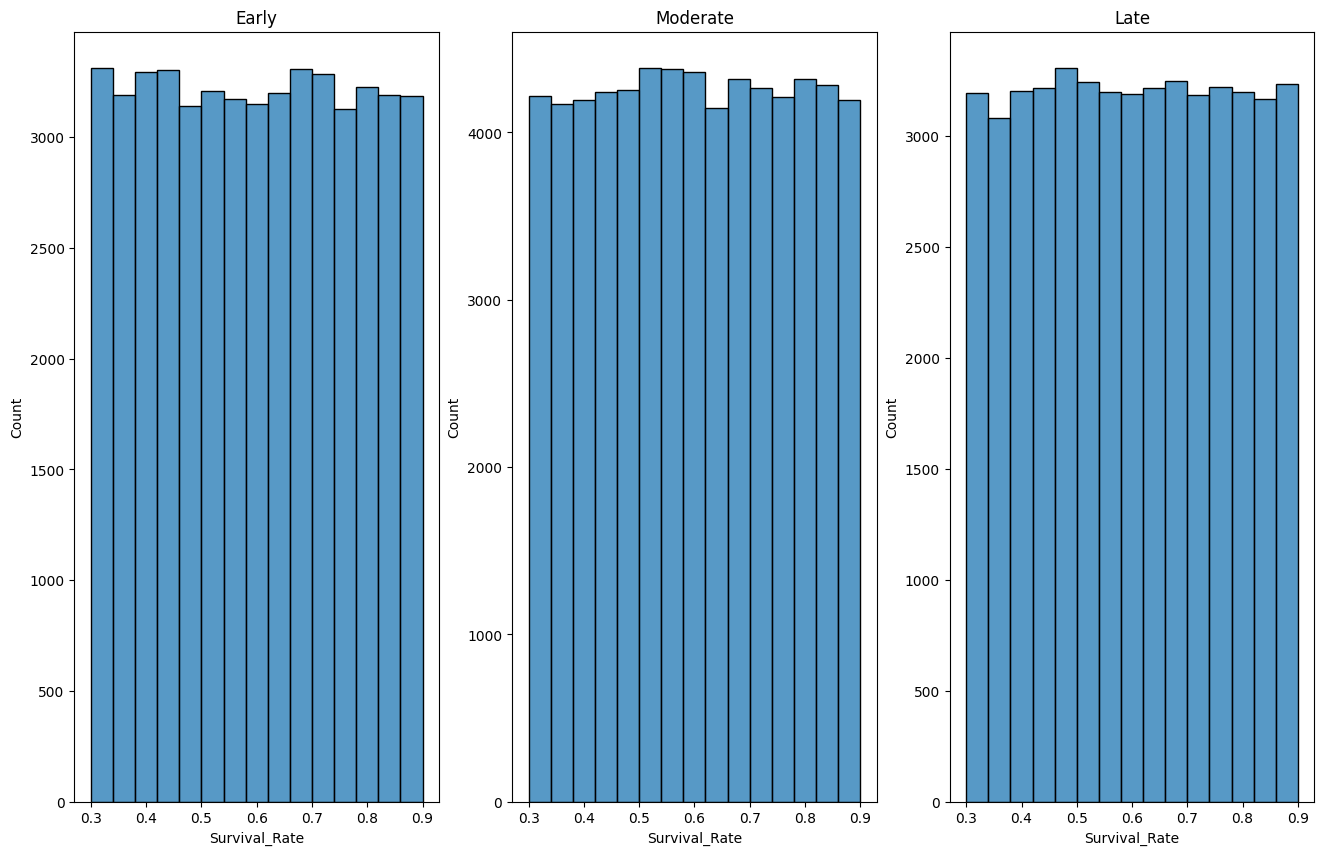

In [7]:
fig , axs = plt.subplots(ncols=3,nrows=1,figsize=(16,10))

i = 0
for diag in df["Diagnosis_Stage"].unique():
    sns.histplot(df[df["Diagnosis_Stage"]==diag],x="Survival_Rate", ax=axs[i],bins=15)
    axs[i].set_title(diag)
    i+=1

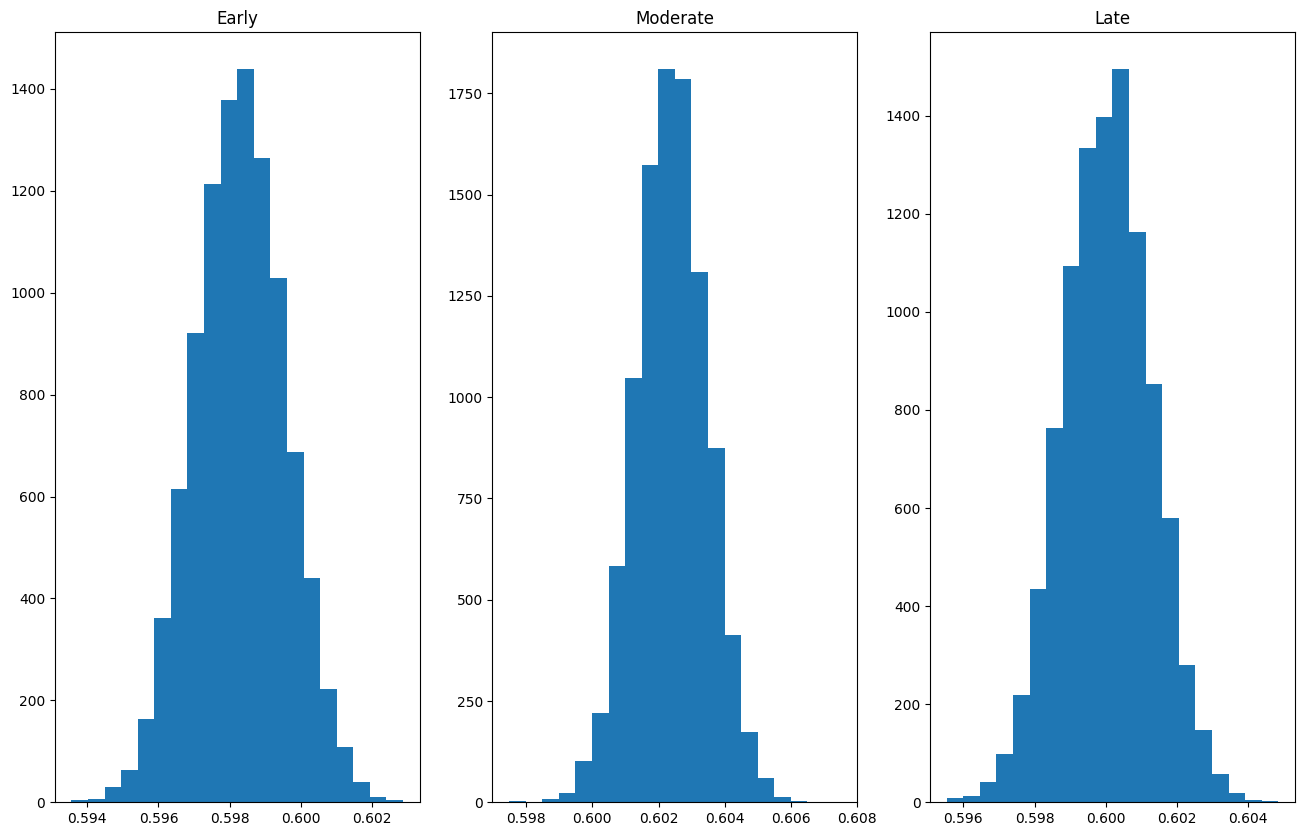

In [13]:
fig , axs = plt.subplots(ncols=3,nrows=1,figsize=(16,10))

i = 0
for diag in df["Diagnosis_Stage"].unique():
    dados = (df[df["Diagnosis_Stage"]==diag]["Survival_Rate"].sample(frac=0.4),)
    dist = st.bootstrap(dados,np.mean)
    axs[i].hist(dist.bootstrap_distribution,bins=20)
    axs[i].set_title(diag)
    i+=1